In [38]:
# Task 1 - Data Loading and Inspection
# # Load q1_heart_disease.csv and display its shape, data types, and missing value counts. 
# Show the first five rows.

import pandas as pd

# Load the dataset
df = pd.read_csv('../data/q1_heart_disease.csv')

# Display the shape of the dataset
print("Shape of the dataset:", df.shape)

# Display data types of each column
print("\nData types of each column:\n", df.dtypes)

# Display count of missing values in each column
print("\nMissing value counts in each column:\n", df.isnull().sum())

# Display the first five rows of the dataset
print("\nFirst five rows of the dataset:\n", df.head())



Shape of the dataset: (800, 12)

Data types of each column:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing value counts in each column:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First five rows of the dataset:
    age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0    

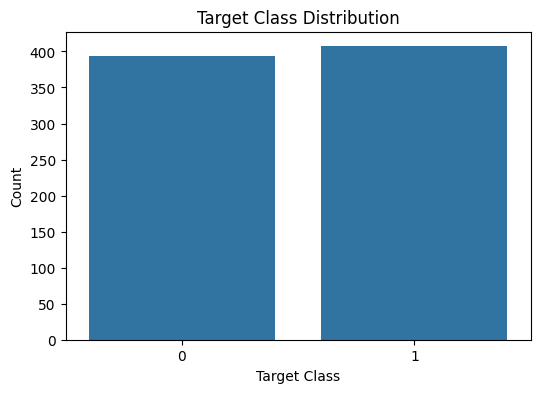

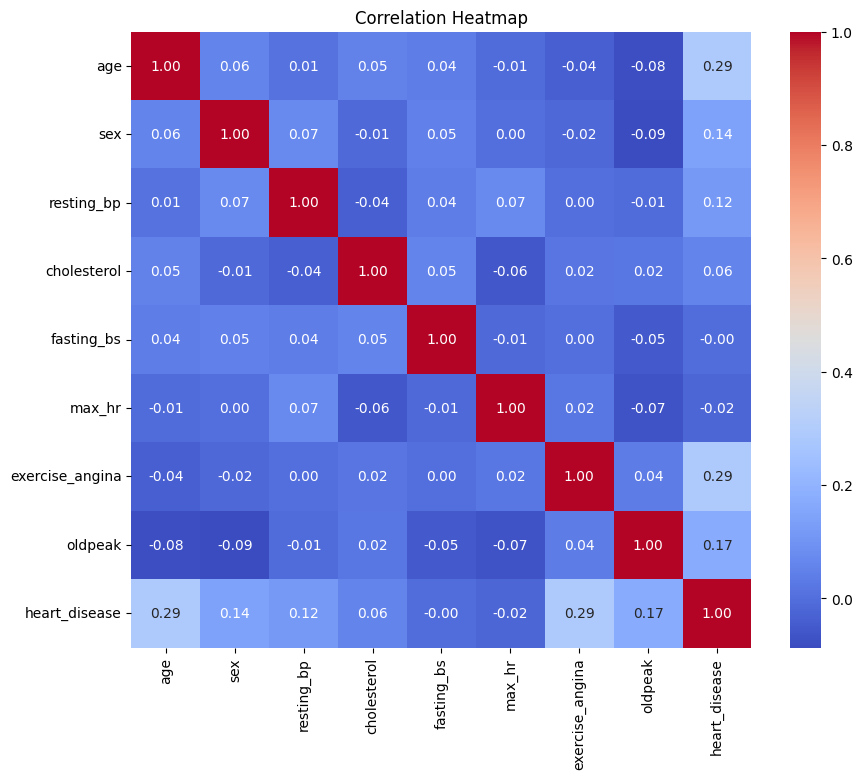

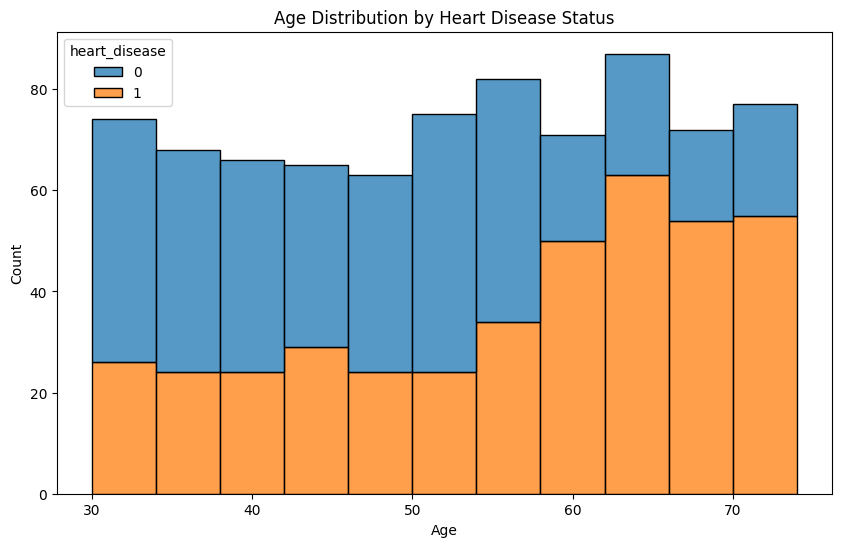

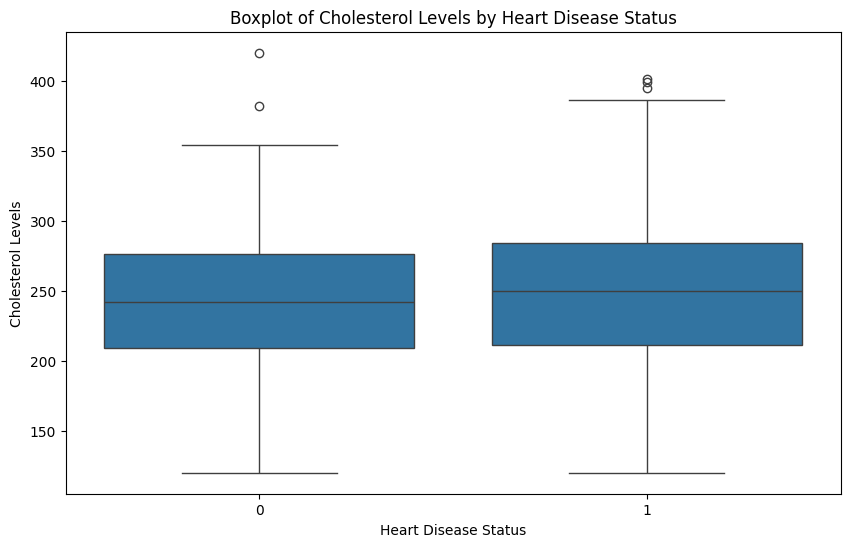

In [39]:
# Task 2 - Exploratory Data Analysis
# Produce at least three visualisations — 
# Include at minimum a target class distribution plot and a correlation heatmap. 
# Follow each plot with a markdown cell interpreting what the chart reveals about the data.

import matplotlib.pyplot as plt
import seaborn as sns

# First Target class distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(x='heart_disease', data=df)
plt.title('Target Class Distribution')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()
# Interpretation:
# The target class distribution plot shows the count of instances for each class in the 'heart_disease' column.
# If the classes are imbalanced (e.g., one class has significantly more instances than the other), 
# it may indicate a need for techniques to address class imbalance during model training.

# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include='number').corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
# Interpretation:
# The correlation heatmap shows the pairwise correlations between numerical features in the dataset.
# Strong positive correlations (values close to 1) indicate that as one feature increases, the other feature also tends to increase.
# Strong negative correlations (values close to -1) indicate that as one feature increases, the other feature tends to decrease.
# Identifying highly correlated features can help in feature selection and understanding relationships between variables.

# Second visualisation - Age distribution by heart disease status
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='heart_disease', multiple='stack')
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()
# Interpretation:
# The age distribution plot shows how the age of individuals is distributed across those with and without heart disease.
# If there is a noticeable difference in age distribution between the two groups, it may suggest that age is a significant factor in heart disease risk. 
# For example, if individuals with heart disease tend to be older, it may indicate that age is a risk factor for heart disease.

# Third visualisation - Boxplot of cholesterol levels by heart disease status
plt.figure(figsize=(10, 6))
sns.boxplot(x='heart_disease', y='cholesterol', data=df)
plt.title('Boxplot of Cholesterol Levels by Heart Disease Status')
plt.xlabel('Heart Disease Status')
plt.ylabel('Cholesterol Levels')
plt.show()
# Interpretation:
# The boxplot of cholesterol levels by heart disease status shows the distribution of cholesterol levels for individuals with and without heart disease.
# If the median cholesterol level is higher for individuals with heart disease compared to those without, it may suggest that higher cholesterol levels are associated with an increased risk of heart disease.
# Additionally, the presence of outliers in the boxplot may indicate that there are individuals with exceptionally high cholesterol levels, which could be a point of interest for further analysis.




## Task 3 - Data Preprocessing

### Missing Value Strategy: Median Imputation

Median imputation is chosen to handle missing values because it is a robust method that is less affected by outliers compared to mean imputation. 
It provides a central tendency measure that can effectively fill in missing values without skewing the distribution of the data. 
This is particularly important in medical datasets where outliers can be common and may represent significant cases that should not be ignored.

In [40]:
# Task 3 - Data Preprocessing —
# Handle missing values with a documented strategy (e.g., median imputation, row drop — justify your choice in a markdown cell)
# Handle missing values using median imputation

# Justification:
# Median imputation is chosen to handle missing values because it is a robust method that is less affected by outliers compared to mean imputation. 
# It provides a central tendency measure that can effectively fill in missing values without skewing the distribution of the data. 
# This is particularly important in medical datasets where outliers can be common and may represent significant cases that should not be ignored.

# Perform median imputation for numerical columns
numerical_cols = df.select_dtypes(include='number').columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# For categorical columns, we can choose to fill missing values with the mode (most frequent value) or a placeholder value.
categorical_cols = df.select_dtypes(include=['str', 'object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    
# After imputation, check for any remaining missing values
print("\nMissing value counts after imputation:\n", df.isnull().sum())

# Apply one-hot encoding to all categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Scale numerical features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Split first, then scale to avoid data leakage
from sklearn.model_selection import train_test_split
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Fit scaler on training data only, then transform both
numerical_features = X_train.select_dtypes(include='number').columns
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])





Missing value counts after imputation:
 age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


In [41]:
# Task 4 - Model Training
# Train the following three models using scikit-learn. Fix random_state=42 for all

# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [42]:
# Task 5 - Model Evaluation. For each model, print:
# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

# Precision, Recall, and F1-score on the test set
models = {'Decision Tree': dt_model, 'Random Forest': rf_model, 'Gradient Boosting': gb_model}
for name, model in models.items():
    print(f"\n{name} Evaluation:")
    y_pred = model.predict(X_test)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    



Decision Tree Evaluation:
Confusion Matrix:
 [[57 22]
 [25 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest Evaluation:
Confusion Matrix:
 [[61 18]
 [15 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting Evaluation:
Confusion Matrix:
 [[61 18]
 [19 62]]
Classification Report:
               precision    recall  f1-score   support

           0       0

## Task 5 - Model Comparison

Based on the evaluation metrics, **Random Forest** performs best:

- **Decision Tree**: Accuracy 71%,  Precision 0.71,  Recall 0.71,  F1 0.71
- **Random Forest**: Accuracy 79%,  Precision 0.79,  Recall 0.79,  F1 0.79
- **Gradient Boosting**: Accuracy 77%,  Precision 0.77,  Recall 0.77,  F1 0.77

Random Forest is the best model not just because of highest accuracy, but because 
it achieves the best balance of precision and recall across both classes (0 and 1). 
High recall for class 1 (0.81) is particularly important in a medical context — 
it means fewer false negatives, i.e., fewer patients with heart disease being 
incorrectly classified as healthy.

Decision Tree performs worst, likely due to overfitting on the training data.

In [43]:
# Task 6 - Hyperparameter Tuning
# Tune at least one hyperparameter on your best-performing model using GridSearchCV. 
# Report the best parameters found and compare the tuned model's test performance against the untuned baseline.

from sklearn.model_selection import GridSearchCV
# Assuming Random Forest performed the best, we will tune it
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Best parameters found
print("Best parameters found:", grid_search.best_params_)

# Evaluate the tuned model on the test set
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)
print("\nTuned Random Forest Evaluation:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("Classification Report:\n", classification_report(y_test, y_pred_tuned))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END ma